# 🔗 COPOD — Copula-Based Outlier Detection

**COPOD**, özellikler arasındaki **bağımlılık yapısını** (dependency structure) modelleyerek anomali tespit eden bir algoritmadır.  
Temelinde **Copula teorisi** yatar: her özelliği kendi dağılımına göre normalize eder, sonra birleşik olasılık hesaplar.

---

### 🧠 Temel Sezgi

```
Adım 1 — ECDF:     Ham veri  →  [0,1] aralığına uniform dönüşüm
                   Her özellik kendi ampirik dağılımıyla ölçeklenir

Adım 2 — Copula:   Uniform değerler  →  log-olasılık (skewed Copula)
                   Sol kuyruk + Sağ kuyruk bağımsız modellenir

Adım 3 — Skor:     Düşük log-olasılık  →  Yüksek anomali skoru
```

### 📐 One-Class SVM / Isolation Forest'ten Farkı

| | COPOD | Isolation Forest | One-Class SVM |
|---|---|---|---|
| **Yaklaşım** | Olasılıksal (copula) | Ağaç izolasyonu | Kernel sınırı |
| **Bağımlılık** | Modeller | Yok sayar | Kernel ile yakalar |
| **Hız** | Çok hızlı | Hızlı | Yavaş |
| **Parametre** | Sadece `contamination` | 3–4 parametre | `nu`, `gamma` |
| **Yorumlanabilirlik** | Yüksek (ECDF tabanlı) | Orta | Düşük |

---

### 📌 Kullanım Senaryoları
- Finansal işlem anomalileri (korelasyonlu özellikler)
- Çok boyutlu sensör verisi izleme
- Biyomedikal veri kalite kontrolü
- Sigorta risk analizi

---

## 📦 1. Kütüphanelerin İçe Aktarılması

In [1]:
# ── Sayısal İşlemler ──────────────────────────────────────────────────────
import numpy as np          # dizi/matris işlemleri, rastgele sayı üretimi
import scipy.stats as stats # istatistiksel dağılımlar ve ECDF hesabı

# ── Görselleştirme ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt          # 2D grafik
import matplotlib.gridspec as gridspec   # esnek alt grafik düzeni
from matplotlib.colors import LinearSegmentedColormap  # özel renk haritası

# ── Makine Öğrenmesi ──────────────────────────────────────────────────────
from pyod.models.copod import COPOD      # ana modelimiz: Copula tabanlı anomali tespiti
                                         # pyod = Python Outlier Detection kütüphanesi

# Karşılaştırma modelleri
from pyod.models.iforest import IForest  # pyod wrapper: Isolation Forest
from pyod.models.ocsvm import OCSVM      # pyod wrapper: One-Class SVM

# Değerlendirme metrikleri
from sklearn.metrics import (roc_auc_score,        # eşiksiz performans ölçümü
                              average_precision_score, # anomali sınıfı için hassasiyet
                              classification_report)   # detaylı sınıflandırma raporu
from sklearn.preprocessing import StandardScaler    # özellik ölçekleme
from sklearn.datasets import make_blobs             # yapay veri üretici

# Grafiklerin daha temiz görünmesi için stil ayarı
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['grid.alpha']       = 0.3

print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


## 🧮 2. Copula Teorisi — Kısa Özet

COPOD'un kalbinde **Empirical Copula** yatar. Adımları elle gösterelim.

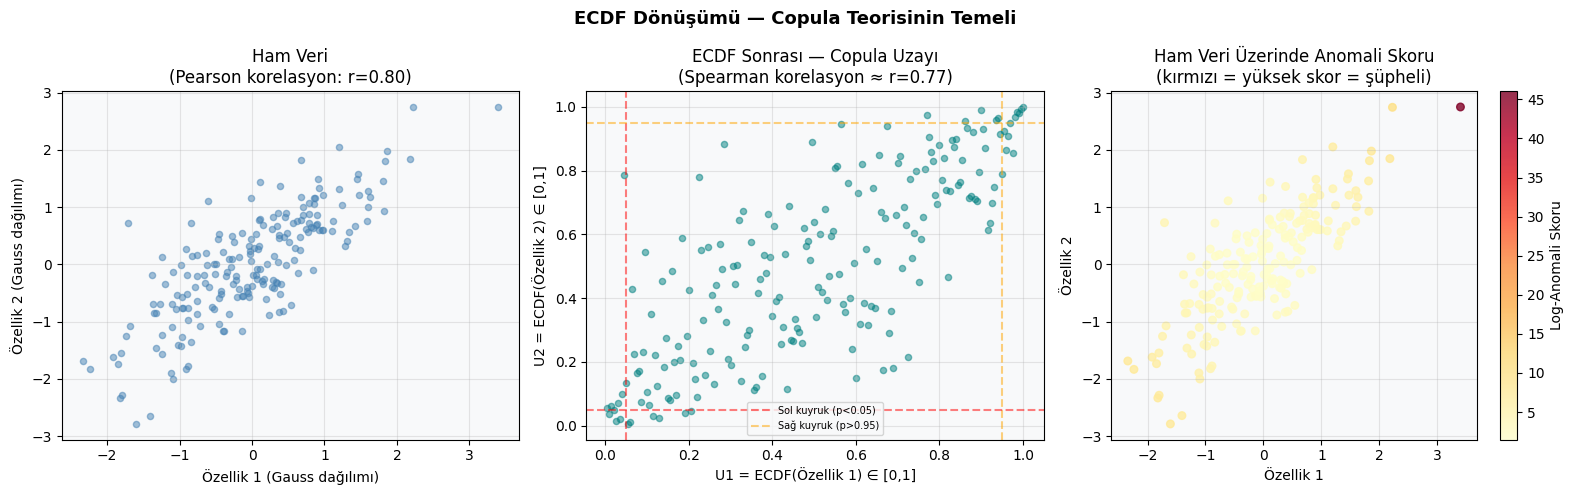

📸 copula_teori.png kaydedildi

Ham veri korelasyonu   : 0.7974
Copula uzayı korelasyonu: 0.7729
→ Korelasyon yapısı ECDF dönüşümünden SONRA da korunur (Sklar Teoremi)


In [2]:
np.random.seed(42)

# ─── Korelasyonlu Örnek Veri ──────────────────────────────────────────────
# Gerçek hayatta özellikler bağımsız değildir
# Örnek: sıcaklık ve basınç arasında pozitif korelasyon var

n_demo = 200  # gösterim için nokta sayısı

# Kovaryans matrisi: özellikler arası korelasyonu tanımlar
# [[1.0, 0.8],  → X1-X1 varyans=1, X1-X2 korelasyon=0.8
#  [0.8, 1.0]]  → X2-X1 korelasyon=0.8, X2-X2 varyans=1
cov_matrix = [[1.0, 0.8],
              [0.8, 1.0]]

# Çok değişkenli normal dağılımdan örnekle
# mean=[0,0]: her iki özelliğin ortalaması sıfır
X_demo = np.random.multivariate_normal(mean=[0, 0], cov=cov_matrix, size=n_demo)

# ─── ECDF Dönüşümü ─────────────────────────────────────────────────────────
# ECDF = Empirical Cumulative Distribution Function (Ampirik Kümülatif Dağılım)
# Her değeri kendi sütununun yüzdelik dilimine (0-1 arasına) dönüştürür
# stats.rankdata: her değere sıralama sayısı atar (1'den n'e)
# / n_demo: sıralamayı [0,1] aralığına normalize eder
U1 = stats.rankdata(X_demo[:, 0]) / n_demo  # 1. özelliğin ECDF dönüşümü
U2 = stats.rankdata(X_demo[:, 1]) / n_demo  # 2. özelliğin ECDF dönüşümü

# ─── Görselleştir ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ECDF Dönüşümü — Copula Teorisinin Temeli', fontsize=13, fontweight='bold')

# Panel 1: Ham veri (korelasyonlu)
ax = axes[0]
ax.scatter(X_demo[:, 0], X_demo[:, 1], alpha=0.5, s=20, c='steelblue')
corr = np.corrcoef(X_demo[:, 0], X_demo[:, 1])[0, 1]  # Pearson korelasyonu
ax.set_title(f'Ham Veri\n(Pearson korelasyon: r={corr:.2f})')
ax.set_xlabel('Özellik 1 (Gauss dağılımı)')
ax.set_ylabel('Özellik 2 (Gauss dağılımı)')
ax.grid(True)

# Panel 2: ECDF sonrası (Copula uzayı)
ax = axes[1]
ax.scatter(U1, U2, alpha=0.5, s=20, c='teal')
corr_u = np.corrcoef(U1, U2)[0, 1]  # Copula uzayındaki korelasyon
ax.set_title(f'ECDF Sonrası — Copula Uzayı\n(Spearman korelasyon ≈ r={corr_u:.2f})')
ax.set_xlabel('U1 = ECDF(Özellik 1) ∈ [0,1]')
ax.set_ylabel('U2 = ECDF(Özellik 2) ∈ [0,1]')
# [0,1] sınırlarını göster
ax.axvline(0.05, color='red', linestyle='--', alpha=0.5, label='Sol kuyruk (p<0.05)')
ax.axvline(0.95, color='orange', linestyle='--', alpha=0.5, label='Sağ kuyruk (p>0.95)')
ax.axhline(0.05, color='red', linestyle='--', alpha=0.5)
ax.axhline(0.95, color='orange', linestyle='--', alpha=0.5)
ax.legend(fontsize=7)
ax.grid(True)

# Panel 3: Log-olasılık skoru (anomali skoru)
ax = axes[2]
# Basit skor: -log(U) → sol kuyruk için (küçük U = olağandışı düşük değer)
# -log(1-U) → sağ kuyruk için (büyük U = olağandışı yüksek değer)
# Her iki kuyruğu birleştir
log_score = np.maximum(-np.log(U1 + 1e-10), -np.log(1 - U1 + 1e-10)) + \
            np.maximum(-np.log(U2 + 1e-10), -np.log(1 - U2 + 1e-10))
sc = ax.scatter(X_demo[:, 0], X_demo[:, 1], c=log_score,
                cmap='YlOrRd', s=30, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Log-Anomali Skoru')
ax.set_title('Ham Veri Üzerinde Anomali Skoru\n(kırmızı = yüksek skor = şüpheli)')
ax.set_xlabel('Özellik 1')
ax.set_ylabel('Özellik 2')
ax.grid(True)

plt.tight_layout()
plt.savefig('copula_teori.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 copula_teori.png kaydedildi")
print(f"\nHam veri korelasyonu   : {corr:.4f}")
print(f"Copula uzayı korelasyonu: {corr_u:.4f}")
print("→ Korelasyon yapısı ECDF dönüşümünden SONRA da korunur (Sklar Teoremi)")

## 🗂️ 3. Veri Üretimi — Gerçekçi Senaryo

**Senaryo:** Bir bankanın işlem verisi  
- Özellikler: `işlem tutarı`, `işlem frekansı`, `risk skoru`, `coğrafi sapma`  
- Normal işlemler birbiriyle **korelasyonlu** (yüksek tutar → yüksek risk skoru)  
- Anomaliler: bu korelasyon yapısını bozan noktalar

In [3]:
np.random.seed(42)

n_train   = 400   # eğitim seti: yalnızca normal işlemler
n_normal  = 120   # test: normal işlemler
n_anomaly = 30    # test: anormal işlemler (%20 anomali oranı)

# ─── 4 Özellikli Kovaryans Matrisi ───────────────────────────────────────
# Gerçek finansal veriler arası korelasyonu temsil eder
# Satır/Sütun: [tutar, frekans, risk, coğrafi_sapma]
#        tutar  freq   risk   geo
cov = [[ 1.00,  0.70,  0.65,  0.30],   # tutar: freq ve riskle güçlü korelasyon
       [ 0.70,  1.00,  0.50,  0.20],   # frekans
       [ 0.65,  0.50,  1.00,  0.40],   # risk skoru
       [ 0.30,  0.20,  0.40,  1.00]]   # coğrafi sapma: diğerleriyle zayıf korelasyon

# ─── EĞİTİM VERİSİ — Yalnızca Normal ─────────────────────────────────────
# Çok değişkenli normal dağılım: kovaryans matrisi korelasyonu içerir
X_train = np.random.multivariate_normal(
    mean=[0, 0, 0, 0],  # 4 özelliğin ortalaması sıfır
    cov=cov,
    size=n_train
)

# ─── TEST VERİSİ — Normal ─────────────────────────────────────────────────
X_test_normal = np.random.multivariate_normal(
    mean=[0, 0, 0, 0],
    cov=cov,
    size=n_normal
)

# ─── TEST VERİSİ — Anormal (3 tip) ────────────────────────────────────────
# Tip 1: Çok yüksek değerler — kuyruklarda yer alan noktalar (10 adet)
# Korelasyon yapısına uysa da uç değerler anomali sayılabilir
X_anom_extreme = np.random.multivariate_normal(
    mean=[3.5, 3.5, 3.5, 3.5],  # ortalamanın çok uzağı
    cov=np.eye(4) * 0.3,         # np.eye: birim matris (bağımsız, düşük varyans)
    size=10
)

# Tip 2: Korelasyon yapısını bozan noktalar (10 adet)
# Yüksek tutar ama düşük risk skoru — banka kurallarına aykırı!
X_anom_corr = np.column_stack([
    np.random.uniform(3, 5, 10),   # özellik 1: çok yüksek tutar
    np.random.uniform(-3, -1, 10), # özellik 2: çok düşük frekans (korelasyona aykırı)
    np.random.uniform(3, 5, 10),   # özellik 3: yüksek risk
    np.random.uniform(-2, 0, 10)   # özellik 4: negatif coğrafi sapma
])

# Tip 3: Gürültülü anomaliler — geniş alanda dağılmış (10 adet)
X_anom_noise = np.random.uniform(low=-5, high=5, size=(10, 4))

# Tüm anomalileri birleştir
X_test_anomaly = np.vstack([X_anom_extreme, X_anom_corr, X_anom_noise])

# ─── Test seti ve gerçek etiketler ────────────────────────────────────────
X_test = np.vstack([X_test_normal, X_test_anomaly])

# pyod etiketi: 0 = normal (inlier), 1 = anormal (outlier)
# Not: One-Class SVM +1/-1 kullanıyordu; pyod 0/1 kullanır!
y_true = np.array([0] * n_normal + [1] * len(X_test_anomaly))

print(f"Eğitim seti    : {X_train.shape}  → {n_train} normal işlem")
print(f"Test seti      : {X_test.shape}  → {n_normal} normal + {len(X_test_anomaly)} anormal")
print(f"Özellik sayısı : 4 (tutar, frekans, risk, coğrafi sapma)")
print(f"Anomali oranı  : %{len(X_test_anomaly)/len(X_test)*100:.1f}")
print(f"\nKorelasyon matrisi (eğitim):")
corr_matrix = np.corrcoef(X_train.T)  # .T: her sütun bir özellik
feat_names = ['Tutar', 'Frekans', 'Risk', 'Coğrafi']
for i, row in enumerate(corr_matrix):
    print(f"  {feat_names[i]:8s}: " + "  ".join(f"{v:+.2f}" for v in row))

Eğitim seti    : (400, 4)  → 400 normal işlem
Test seti      : (150, 4)  → 120 normal + 30 anormal
Özellik sayısı : 4 (tutar, frekans, risk, coğrafi sapma)
Anomali oranı  : %20.0

Korelasyon matrisi (eğitim):
  Tutar   : +1.00  +0.68  +0.58  +0.20
  Frekans : +0.68  +1.00  +0.46  +0.12
  Risk    : +0.58  +0.46  +1.00  +0.34
  Coğrafi : +0.20  +0.12  +0.34  +1.00


## 📊 4. Korelasyon Yapısını Görselleştir

COPOD'un en güçlü olduğu durum: özellikler **korelasyonlu** olduğunda.

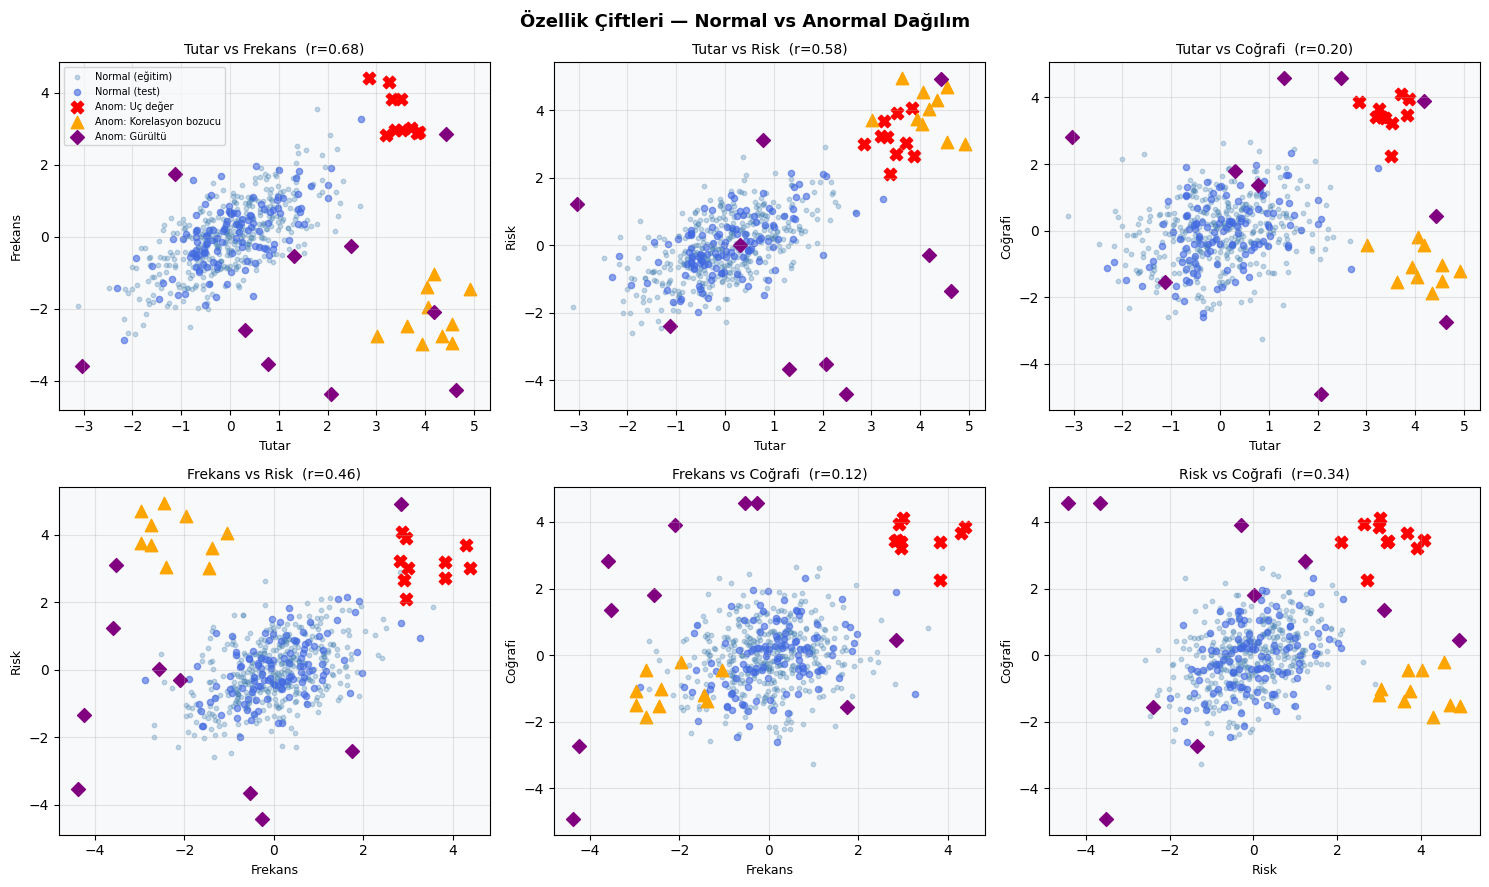

📸 ozellik_ciftleri.png kaydedildi


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Özellik Çiftleri — Normal vs Anormal Dağılım', fontsize=13, fontweight='bold')

# 4 özelliğin tüm ikili kombinasyonları: (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)
import itertools
pairs = list(itertools.combinations(range(4), 2))  # combinations: tekrarsız çiftler

for idx, (i, j) in enumerate(pairs):
    ax = axes[idx // 3][idx % 3]  # 2x3 ızgarada konumu hesapla

    # Normal eğitim noktaları
    ax.scatter(X_train[:, i], X_train[:, j],
               c='steelblue', s=10, alpha=0.3, label='Normal (eğitim)')

    # Normal test noktaları
    ax.scatter(X_test_normal[:, i], X_test_normal[:, j],
               c='royalblue', s=20, alpha=0.6, label='Normal (test)')

    # Anormal test noktaları: 3 tipi farklı renk
    ax.scatter(X_anom_extreme[:, i], X_anom_extreme[:, j],
               c='red', marker='X', s=80, label='Anom: Uç değer')
    ax.scatter(X_anom_corr[:, i], X_anom_corr[:, j],
               c='orange', marker='^', s=80, label='Anom: Korelasyon bozucu')
    ax.scatter(X_anom_noise[:, i], X_anom_noise[:, j],
               c='purple', marker='D', s=50, label='Anom: Gürültü')

    # Korelasyon katsayısını hesapla ve başlığa ekle
    r = np.corrcoef(X_train[:, i], X_train[:, j])[0, 1]
    ax.set_title(f'{feat_names[i]} vs {feat_names[j]}  (r={r:.2f})', fontsize=10)
    ax.set_xlabel(feat_names[i], fontsize=9)
    ax.set_ylabel(feat_names[j], fontsize=9)
    ax.grid(True, alpha=0.3)

    if idx == 0:  # Sadece ilk panelde legend göster
        ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('ozellik_ciftleri.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 ozellik_ciftleri.png kaydedildi")

## ⚖️ 5. Özellik Ölçekleme

In [5]:
scaler = StandardScaler()

# fit_transform: eğitim verisinden ortalama/std öğren VE dönüştür
# Sonuç: her özellik ortalama=0, std=1 olur
X_train_s = scaler.fit_transform(X_train)

# transform: SADECE dönüştür — scaler'ı test verisiyle fit ETME
# Test verisinin bilgisi eğitime sızmamalı (data leakage önleme)
X_test_s  = scaler.transform(X_test)

print("Ölçekleme sonuçları (eğitim verisi):")
for i, name in enumerate(feat_names):
    mu  = X_train_s[:, i].mean()
    std = X_train_s[:, i].std()
    print(f"  {name:8s}: ortalama={mu:+.6f}  std={std:.6f}")
print("\n✅ Tüm özellikler ortalama≈0 ve std≈1")

Ölçekleme sonuçları (eğitim verisi):
  Tutar   : ortalama=-0.000000  std=1.000000
  Frekans : ortalama=-0.000000  std=1.000000
  Risk    : ortalama=+0.000000  std=1.000000
  Coğrafi : ortalama=+0.000000  std=1.000000

✅ Tüm özellikler ortalama≈0 ve std≈1


## 🔗 6. COPOD Modeli — Tanım ve Hiperparametreler

### COPOD'un Hesaplama Adımları:

1. **ECDF** → Her özelliği `[0,1]` aralığına uniform dönüştür
2. **Sol Kuyruk Skoru** → `skewness_left[j]  = -log(ECDF(x_j))`  
   (küçük değerler: sol kuyrukta olağandışı)
3. **Sağ Kuyruk Skoru** → `skewness_right[j] = -log(1 - ECDF(x_j))`  
   (büyük değerler: sağ kuyrukta olağandışı)
4. **Skewness Düzeltme** → asimetrik dağılımlarda dominant kuyruğu seç
5. **Birleşik Skor** → tüm özellikler toplanır → anomali skoru

In [6]:
# ─── COPOD Modeli ─────────────────────────────────────────────────────────
copod = COPOD(
    contamination=0.20,   # Beklenen anomali oranı: test setimizde %20 anomali var
                          # Bu değer karar eşiğini (threshold) belirler
                          # Eğitim verisindeki puanların üst %contamination'ı anomali sayılır

    n_jobs=1              # Paralel iş parçacığı sayısı
                          # -1: tüm CPU çekirdeklerini kullan
                          #  1: tek çekirdek (tekrar üretilebilirlik için)
)

print("✅ COPOD modeli oluşturuldu:")
print(f"   contamination : {copod.contamination}")
print(f"   n_jobs        : {copod.n_jobs}")
print()
print("📌 COPOD parametresi çok azdır — ana güçlü yönü bu!")
print("   Isolation Forest: n_estimators, max_samples, max_features, contamination")
print("   One-Class SVM   : kernel, nu, gamma")
print("   COPOD           : sadece contamination")

✅ COPOD modeli oluşturuldu:
   contamination : 0.2
   n_jobs        : 1

📌 COPOD parametresi çok azdır — ana güçlü yönü bu!
   Isolation Forest: n_estimators, max_samples, max_features, contamination
   One-Class SVM   : kernel, nu, gamma
   COPOD           : sadece contamination


## 🏋️ 7. Modeli Eğitme

In [7]:
# fit(): her özellik için ECDF hesaplar, copula tablosunu oluşturur
# Sadece normal eğitim verisi görür — anormal veri GÖRMEMELİ
# pyod'da fit() hem eğitir hem eğitim verisini tahmin eder
copod.fit(X_train_s)

# Eğitim sonrası otomatik oluşan özellikler:
# copod.labels_         : eğitim verisi için 0/1 etiketler
# copod.decision_scores_: eğitim verisi için anomali skorları (yüksek = anormal)
# copod.threshold_      : contamination'a göre belirlenen karar eşiği

n_outliers_train = copod.labels_.sum()  # eğitimde kaç nokta outlier sayıldı?

print(f"✅ Model eğitildi — {len(X_train_s)} normal nokta")
print(f"\nEğitim istatistikleri:")
print(f"  Karar Eşiği (threshold) : {copod.threshold_:.4f}")
print(f"  Eğitimde outlier sayısı  : {n_outliers_train} / {len(X_train_s)}")
print(f"  Skor aralığı             : [{copod.decision_scores_.min():.3f}, {copod.decision_scores_.max():.3f}]")
print(f"  Skor ortalaması          : {copod.decision_scores_.mean():.3f}")

✅ Model eğitildi — 400 normal nokta

Eğitim istatistikleri:
  Karar Eşiği (threshold) : 6.5435
  Eğitimde outlier sayısı  : 80 / 400
  Skor aralığı             : [2.839, 14.902]
  Skor ortalaması          : 5.331


## 🔮 8. Test Verisi — Tahmin ve Anomali Skorları

In [8]:
# predict(): her test noktası için 0 (normal) veya 1 (anormal) döner
# Karar: anomali_skoru > threshold → 1, değilse → 0
y_pred = copod.predict(X_test_s)

# decision_function(): normalize edilmiş anomali skoru döner
# Yüksek değer = daha anormal
# pyod'da decision_function = decision_scores_ ile aynı mantık
scores = copod.decision_function(X_test_s)

# predict_proba(): [normal_olasılığı, anormal_olasılığı] çifti döner
# NOT: COPOD gerçek olasılık değil, normalize skor döner
proba = copod.predict_proba(X_test_s)

# ─── Performans Metrikleri ────────────────────────────────────────────────
TP = ((y_pred == 0) & (y_true == 0)).sum()  # Doğru normal
TN = ((y_pred == 1) & (y_true == 1)).sum()  # Doğru anomali
FP = ((y_pred == 0) & (y_true == 1)).sum()  # Kaçan anomali
FN = ((y_pred == 1) & (y_true == 0)).sum()  # Yanlış alarm

accuracy  = (y_pred == y_true).mean() * 100

# Recall: anomalilerin kaçını yakaladık? TN/(TN+FP)
recall    = TN / (TN + FP) * 100 if (TN + FP) > 0 else 0

# Precision: anomali dediğimizin kaçı gerçekten anomali? TN/(TN+FN)
precision = TN / (TN + FN) * 100 if (TN + FN) > 0 else 0

# ROC-AUC: eşikten bağımsız genel performans (1.0 = mükemmel)
auc = roc_auc_score(y_true, scores)

# Average Precision: anomali sınıfı için hassasiyet-geri çağırma eğrisi altındaki alan
ap  = average_precision_score(y_true, scores)

print("📊 TEST SONUÇLARI")
print("=" * 50)
print(f"Genel Doğruluk        : %{accuracy:.1f}")
print(f"Anomali Recall        : %{recall:.1f}   (kaç anomali yakalandı?)")
print(f"Anomali Precision     : %{precision:.1f}   (anomali tahminlerinin doğruluğu)")
print(f"ROC-AUC               : {auc:.4f}")
print(f"Average Precision     : {ap:.4f}")
print()
print(f"TP={TP} (doğru normal) | TN={TN} (doğru anomali) | FP={FP} (kaçan) | FN={FN} (yanlış alarm)")
print()
print(f"Skor aralığı — Min: {scores.min():.3f} | Maks: {scores.max():.3f} | Eşik: {copod.threshold_:.3f}")

📊 TEST SONUÇLARI
Genel Doğruluk        : %90.0
Anomali Recall        : %96.7   (kaç anomali yakalandı?)
Anomali Precision     : %67.4   (anomali tahminlerinin doğruluğu)
ROC-AUC               : 0.9875
Average Precision     : 0.9533

TP=106 (doğru normal) | TN=29 (doğru anomali) | FP=1 (kaçan) | FN=14 (yanlış alarm)

Skor aralığı — Min: 3.045 | Maks: 17.379 | Eşik: 6.543


## 📈 9. Anomali Skorlarının Analizi

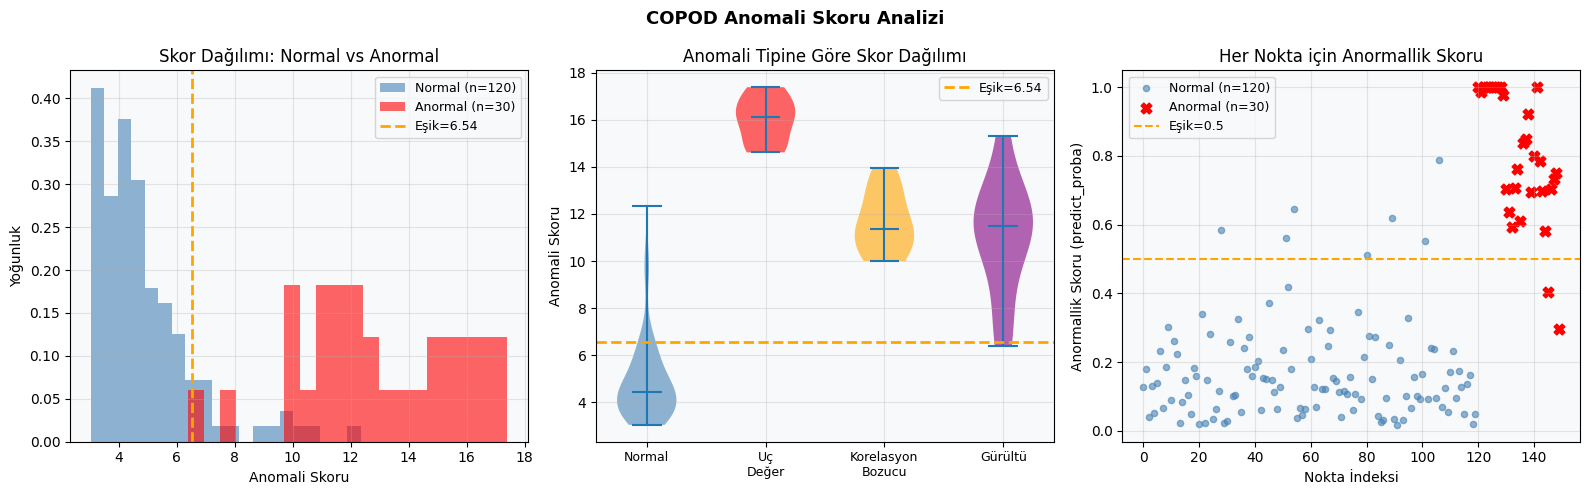

📸 copod_skorlar.png kaydedildi

Ortalama Skor — Normal: 4.897 | Uç: 15.999 | Korelasyon: 11.665 | Gürültü: 11.021


In [9]:
# Normal ve anormal grupların skorlarını ayır
scores_normal  = scores[y_true == 0]  # normal test noktalarının skorları
scores_anomaly = scores[y_true == 1]  # anormal test noktalarının skorları

# Her anormallik tipi için ayrı skorlar (kimin zor tespit edildiğini görmek için)
scores_extreme = scores[n_normal : n_normal + 10]             # Uç değerler
scores_corr    = scores[n_normal + 10 : n_normal + 20]        # Korelasyon bozucu
scores_noise   = scores[n_normal + 20 : n_normal + 30]        # Gürültü

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('COPOD Anomali Skoru Analizi', fontsize=13, fontweight='bold')

# ── Panel 1: Histogram ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(scores_normal,  bins=20, alpha=0.6, color='steelblue',
        density=True, label=f'Normal (n={len(scores_normal)})')
ax.hist(scores_anomaly, bins=20, alpha=0.6, color='red',
        density=True, label=f'Anormal (n={len(scores_anomaly)})')
# Karar eşiğini dikey çizgiyle göster
ax.axvline(copod.threshold_, color='orange', linestyle='--',
           linewidth=2, label=f'Eşik={copod.threshold_:.2f}')
ax.set_xlabel('Anomali Skoru')
ax.set_ylabel('Yoğunluk')
ax.set_title('Skor Dağılımı: Normal vs Anormal')
ax.legend(fontsize=9)
ax.grid(True)

# ── Panel 2: Anomali Tipi Bazında Skor ────────────────────────────────────
ax = axes[1]
# Violin plot: yoğunluk dağılımını gösterir (box plot'tan bilgi açısından zengin)
vp = ax.violinplot(
    [scores_normal, scores_extreme, scores_corr, scores_noise],
    positions=[1, 2, 3, 4],
    showmedians=True,   # ortancayı göster
    showextrema=True    # min/maks çizgilerini göster
)

# Violin renklerini ayarla
colors_vp = ['steelblue', 'red', 'orange', 'purple']
for patch, color in zip(vp['bodies'], colors_vp):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(copod.threshold_, color='orange', linestyle='--',
           linewidth=2, label=f'Eşik={copod.threshold_:.2f}')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Normal', 'Uç\nDeğer', 'Korelasyon\nBozucu', 'Gürültü'], fontsize=9)
ax.set_ylabel('Anomali Skoru')
ax.set_title('Anomali Tipine Göre Skor Dağılımı')
ax.legend(fontsize=9)
ax.grid(True)

# ── Panel 3: Olasılık Skoru (predict_proba) ───────────────────────────────
ax = axes[2]
# predict_proba sütun 1: anormal olma olasılığı
proba_normal  = proba[y_true == 0, 1]  # normal noktaların anormallik olasılığı
proba_anomaly = proba[y_true == 1, 1]  # anormal noktaların anormallik olasılığı

ax.scatter(range(len(proba_normal)), proba_normal,
           c='steelblue', s=20, alpha=0.6, label=f'Normal (n={len(proba_normal)})')
ax.scatter(range(len(proba_normal), len(proba_normal) + len(proba_anomaly)),
           proba_anomaly, c='red', marker='X', s=60, label=f'Anormal (n={len(proba_anomaly)})')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Eşik=0.5')
ax.set_xlabel('Nokta İndeksi')
ax.set_ylabel('Anormallik Skoru (predict_proba)')
ax.set_title('Her Nokta için Anormallik Skoru')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('copod_skorlar.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 copod_skorlar.png kaydedildi")
print(f"\nOrtalama Skor — Normal: {scores_normal.mean():.3f} | Uç: {scores_extreme.mean():.3f} | Korelasyon: {scores_corr.mean():.3f} | Gürültü: {scores_noise.mean():.3f}")

## 🌡️ 10. COPOD Özellik Bazlı Katkı Analizi

COPOD'un önemli özelliği: **hangi özellik anomaliyi tetikledi?** sorusunu yanıtlayabilmek.

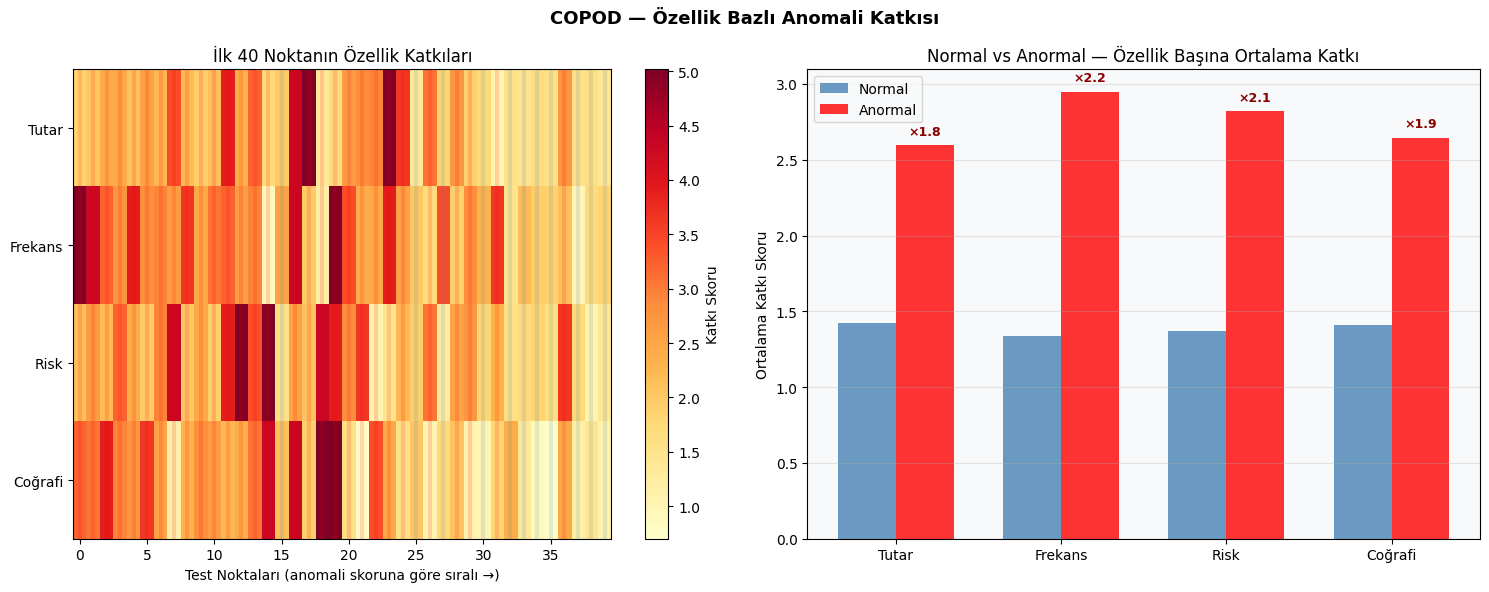

📸 ozellik_katkisi.png kaydedildi

Anormal noktalarda normal noktalara kıyasla özellik katkı oranları:
  Tutar     : ×1.82
  Frekans   : ×2.21
  Risk      : ×2.06
  Coğrafi   : ×1.87


In [10]:
# Her özelliğin anomali skoruna katkısını hesapla
# COPOD'da skew_l (sol) ve skew_r (sağ kuyruk) skorları özellik bazlı saklanır

def compute_feature_contributions(model, X_scaled):
    """
    COPOD modelinin her özellik için ürettiği katkı skorunu hesaplar.
    Yüksek katkı → o özellik anomaliyi tetikliyor.
    """
    n, d = X_scaled.shape  # n: nokta sayısı, d: özellik sayısı
    contributions = np.zeros((n, d))  # sonuç matrisi: n nokta × d özellik

    for j in range(d):  # her özellik için
        col = X_scaled[:, j]  # j. özelliğin tüm değerleri

        # ECDF: her değeri kümülatif olasılığa dönüştür
        # rankdata: küçükten büyüğe sıraya koy (1'den n'e)
        ranks = stats.rankdata(col)
        u = ranks / (n + 1)  # +1: 0 ve 1'den kaçınmak için (log(0) = -sonsuz)

        # Sol kuyruk skoru: -log(u)
        # Küçük u (sol kuyruk değeri) → -log(u) büyük → yüksek anomali skoru
        skew_left  = -np.log(u)

        # Sağ kuyruk skoru: -log(1-u)
        # Büyük u (sağ kuyruk değeri) → -log(1-u) büyük → yüksek anomali skoru
        skew_right = -np.log(1 - u)

        # Her nokta için dominant kuyruğu seç (hangisi daha büyükse)
        contributions[:, j] = np.maximum(skew_left, skew_right)

    return contributions

# Test verisi için özellik katkılarını hesapla
contribs = compute_feature_contributions(copod, X_test_s)

# ─── Isı Haritası (Heatmap) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('COPOD — Özellik Bazlı Anomali Katkısı', fontsize=13, fontweight='bold')

# Test noktalarını anomali skoruna göre sırala (en yüksek üste)
sort_idx = np.argsort(scores)[::-1]  # argsort: sıralamanın indekslerini ver
top_n = 40  # ilk 40 noktayı göster

ax = axes[0]
# imshow: 2D matrisi ısı haritası olarak görselleştir
im = ax.imshow(
    contribs[sort_idx[:top_n]].T,  # .T: özellikler satırda, noktalar sütunda
    cmap='YlOrRd',                  # sarı(düşük) → turuncu → kırmızı(yüksek)
    aspect='auto'                   # hücre boyutunu otomatik ayarla
)
plt.colorbar(im, ax=ax, label='Katkı Skoru')

ax.set_yticks(range(4))
ax.set_yticklabels(feat_names)
ax.set_xlabel('Test Noktaları (anomali skoruna göre sıralı →)')
ax.set_title(f'İlk {top_n} Noktanın Özellik Katkıları')

# Gerçek etiketi alt kenara ekle (0=normal, 1=anomali)
true_labels_sorted = y_true[sort_idx[:top_n]]
for k, label in enumerate(true_labels_sorted):
    color = 'red' if label == 1 else 'steelblue'
    ax.axvline(k, color=color, alpha=0.15, linewidth=3)

# ── Panel 2: Ortalama özellik katkısı (normal vs anormal) ─────────────────
ax = axes[1]
mean_normal  = contribs[y_true == 0].mean(axis=0)  # normal noktaların ort. katkısı
mean_anomaly = contribs[y_true == 1].mean(axis=0)  # anormal noktaların ort. katkısı

x = np.arange(4)       # 4 özellik için x pozisyonu
width = 0.35           # çubuk genişliği

# Yan yana çubuk grafik
ax.bar(x - width/2, mean_normal,  width, label='Normal',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, mean_anomaly, width, label='Anormal', color='red',       alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(feat_names)
ax.set_ylabel('Ortalama Katkı Skoru')
ax.set_title('Normal vs Anormal — Özellik Başına Ortalama Katkı')
ax.legend()
ax.grid(True, axis='y')

# Fark oranını her çubuğun üstüne yaz
for i in range(4):
    ratio = mean_anomaly[i] / mean_normal[i] if mean_normal[i] > 0 else 0
    ax.text(i + width/2, mean_anomaly[i] + 0.05, f'×{ratio:.1f}',
            ha='center', va='bottom', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('ozellik_katkisi.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 ozellik_katkisi.png kaydedildi")
print("\nAnormal noktalarda normal noktalara kıyasla özellik katkı oranları:")
for i, name in enumerate(feat_names):
    ratio = mean_anomaly[i] / mean_normal[i] if mean_normal[i] > 0 else 0
    print(f"  {name:10s}: ×{ratio:.2f}")

## 🏆 11. Üç Model Karşılaştırması

COPOD, Isolation Forest ve One-Class SVM'i aynı veri üzerinde karşılaştır.

In [11]:
# ─── Üç Modeli Eğit ───────────────────────────────────────────────────────
models = {
    'COPOD': COPOD(contamination=0.20, n_jobs=1),
    'Isolation\nForest': IForest(n_estimators=200, contamination=0.20, random_state=42, n_jobs=1),
    'One-Class\nSVM': OCSVM(kernel='rbf', nu=0.20)
}

results = {}  # her modelin sonuçlarını sakla

for name, m in models.items():
    m.fit(X_train_s)                           # sadece normal veriyle eğit
    preds  = m.predict(X_test_s)               # 0/1 tahminler
    sc_m   = m.decision_function(X_test_s)     # sürekli anomali skoru

    tp  = ((preds == 0) & (y_true == 0)).sum()
    tn  = ((preds == 1) & (y_true == 1)).sum()
    fp  = ((preds == 0) & (y_true == 1)).sum()
    fn  = ((preds == 1) & (y_true == 0)).sum()
    acc = (preds == y_true).mean() * 100
    rec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    pre = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0

    # roc_auc_score: y_true=0/1, scores=anomali skoru
    auc_val = roc_auc_score(y_true, sc_m)

    results[name] = {
        'preds': preds, 'scores': sc_m,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Acc': acc, 'Recall': rec, 'Precision': pre, 'AUC': auc_val
    }

# ─── Karşılaştırma Tablosu ────────────────────────────────────────────────
print("┌────────────────────┬──────────┬──────────┬──────────┬──────────┐")
print("│ Model              │ Doğruluk │  Recall  │Precision │ ROC-AUC  │")
print("├────────────────────┼──────────┼──────────┼──────────┼──────────┤")
for name, r in results.items():
    name_clean = name.replace('\n', ' ')
    print(f"│ {name_clean:18s} │  %{r['Acc']:5.1f}  │  %{r['Recall']:5.1f}  │  %{r['Precision']:5.1f}  │  {r['AUC']:.4f}  │")
print("└────────────────────┴──────────┴──────────┴──────────┴──────────┘")

┌────────────────────┬──────────┬──────────┬──────────┬──────────┐
│ Model              │ Doğruluk │  Recall  │Precision │ ROC-AUC  │
├────────────────────┼──────────┼──────────┼──────────┼──────────┤
│ COPOD              │  % 90.0  │  % 96.7  │  % 67.4  │  0.9875  │
│ Isolation Forest   │  % 86.7  │  %100.0  │  % 60.0  │  0.9981  │
│ One-Class SVM      │  % 90.7  │  %100.0  │  % 68.2  │  0.9992  │
└────────────────────┴──────────┴──────────┴──────────┴──────────┘


## 📊 12. ROC Eğrisi ve Model Karşılaştırma Grafikleri

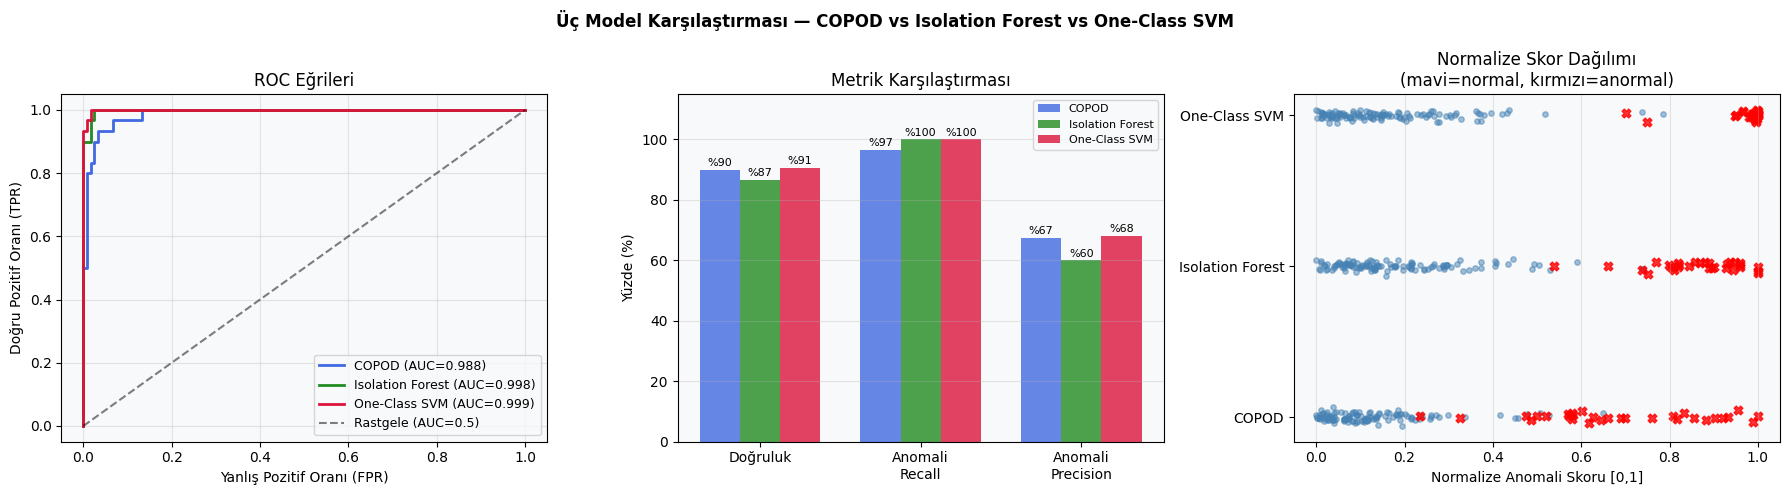

📸 model_karsilastirma.png kaydedildi


In [12]:
from sklearn.metrics import roc_curve  # ROC eğrisini hesapla

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Üç Model Karşılaştırması — COPOD vs Isolation Forest vs One-Class SVM',
             fontsize=12, fontweight='bold')

colors_m = {'COPOD': 'royalblue',
            'Isolation\nForest': 'forestgreen',
            'One-Class\nSVM': 'crimson'}

# ── Panel 1: ROC Eğrileri ─────────────────────────────────────────────────
ax = axes[0]
for name, r in results.items():
    # roc_curve: farklı eşik değerleri için FPR ve TPR hesaplar
    fpr, tpr, _ = roc_curve(y_true, r['scores'])
    ax.plot(fpr, tpr,
            label=f"{name.replace(chr(10),' ')} (AUC={r['AUC']:.3f})",
            color=colors_m[name], linewidth=2)

# Rastgele tahmin referans çizgisi (AUC=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Rastgele (AUC=0.5)')
ax.set_xlabel('Yanlış Pozitif Oranı (FPR)')
ax.set_ylabel('Doğru Pozitif Oranı (TPR)')
ax.set_title('ROC Eğrileri')
ax.legend(fontsize=9)
ax.grid(True)

# ── Panel 2: Çubuk Grafik — Metrik Karşılaştırması ────────────────────────
ax = axes[1]
metric_names = ['Acc', 'Recall', 'Precision']
x = np.arange(len(metric_names))
width = 0.25

for i, (name, r) in enumerate(results.items()):
    vals = [r['Acc'], r['Recall'], r['Precision']]
    offset = (i - 1) * width  # -1, 0, +1 offset
    bars = ax.bar(x + offset, vals, width,
                  label=name.replace('\n', ' '),
                  color=list(colors_m.values())[i], alpha=0.8)
    # Her çubuğun üstüne değer yaz
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'%{val:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['Doğruluk', 'Anomali\nRecall', 'Anomali\nPrecision'])
ax.set_ylabel('Yüzde (%)')
ax.set_ylim(0, 115)
ax.set_title('Metrik Karşılaştırması')
ax.legend(fontsize=8)
ax.grid(True, axis='y')

# ── Panel 3: Anomali Skoru Dağılımı (3 model) ─────────────────────────────
ax = axes[2]
for i, (name, r) in enumerate(results.items()):
    sc = r['scores']
    # Min-Max normalize et (farklı ölçekleri karşılaştırabilmek için)
    sc_norm = (sc - sc.min()) / (sc.max() - sc.min() + 1e-10)

    sc_n = sc_norm[y_true == 0]  # normal noktaların skorları
    sc_a = sc_norm[y_true == 1]  # anormal noktaların skorları

    # KDE benzeri dağılım gösterimi için scatter + jitter
    jitter = np.random.normal(0, 0.04, size=len(sc_n))  # hafif dikey gürültü
    ax.scatter(sc_n, np.full_like(sc_n, i * 2 + 0) + jitter,
               c='steelblue', s=15, alpha=0.5)
    jitter = np.random.normal(0, 0.04, size=len(sc_a))
    ax.scatter(sc_a, np.full_like(sc_a, i * 2 + 0) + jitter,
               c='red', s=40, marker='X', alpha=0.8)

ax.set_yticks([0, 2, 4])
ax.set_yticklabels([n.replace('\n', ' ') for n in results.keys()])
ax.set_xlabel('Normalize Anomali Skoru [0,1]')
ax.set_title('Normalize Skor Dağılımı\n(mavi=normal, kırmızı=anormal)')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 model_karsilastirma.png kaydedildi")

## 🔬 13. Contamination Parametresinin Etkisi

In [13]:
# Farklı contamination değerleri için COPOD performansı
cont_values = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
res_cont = []

for cont in cont_values:
    m = COPOD(contamination=cont, n_jobs=1)
    m.fit(X_train_s)
    preds = m.predict(X_test_s)
    sc    = m.decision_function(X_test_s)

    tn  = ((preds == 1) & (y_true == 1)).sum()  # doğru anomali
    fp  = ((preds == 0) & (y_true == 1)).sum()  # kaçan anomali
    fn  = ((preds == 1) & (y_true == 0)).sum()  # yanlış alarm
    acc = (preds == y_true).mean() * 100
    rec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    auc_v = roc_auc_score(y_true, sc)

    res_cont.append({'cont': cont, 'TN': tn, 'FP': fp, 'FN': fn,
                     'Acc': acc, 'Recall': rec, 'AUC': auc_v,
                     'Threshold': m.threshold_})

print("┌────────────┬──────┬──────┬──────┬──────────┬──────────┬──────────┬──────────┐")
print("│ contaminat │  TN  │  FP  │  FN  │ Doğruluk │  Recall  │  AUC     │  Eşik    │")
print("├────────────┼──────┼──────┼──────┼──────────┼──────────┼──────────┼──────────┤")
for r in res_cont:
    marker = " ◀" if abs(r['cont'] - 0.20) < 0.001 else "  "
    print(f"│    {r['cont']:.2f}    │ {r['TN']:4d} │ {r['FP']:4d} │ {r['FN']:4d} │  %{r['Acc']:5.1f}   │  %{r['Recall']:5.1f}   │  {r['AUC']:.4f}  │  {r['Threshold']:.4f}  │{marker}")
print("└────────────┴──────┴──────┴──────┴──────────┴──────────┴──────────┴──────────┘")
print("\n◀ Seçilen değer | TN=Doğru Anomali | FP=Kaçan | FN=Yanlış Alarm")
print("Not: AUC sabit kalır — contamination sadece eşiği değiştirir, skoru değil!")

┌────────────┬──────┬──────┬──────┬──────────┬──────────┬──────────┬──────────┐
│ contaminat │  TN  │  FP  │  FN  │ Doğruluk │  Recall  │  AUC     │  Eşik    │
├────────────┼──────┼──────┼──────┼──────────┼──────────┼──────────┼──────────┤
│    0.05    │   28 │    2 │    7 │  % 94.0   │  % 93.3   │  0.9875  │  8.7657  │  
│    0.10    │   28 │    2 │    8 │  % 93.3   │  % 93.3   │  0.9875  │  7.7314  │  
│    0.15    │   29 │    1 │   10 │  % 92.7   │  % 96.7   │  0.9875  │  6.9892  │  
│    0.20    │   29 │    1 │   14 │  % 90.0   │  % 96.7   │  0.9875  │  6.5435  │ ◀
│    0.25    │   30 │    0 │   17 │  % 88.7   │  %100.0   │  0.9875  │  6.2787  │  
│    0.30    │   30 │    0 │   23 │  % 84.7   │  %100.0   │  0.9875  │  5.8962  │  
└────────────┴──────┴──────┴──────┴──────────┴──────────┴──────────┴──────────┘

◀ Seçilen değer | TN=Doğru Anomali | FP=Kaçan | FN=Yanlış Alarm
Not: AUC sabit kalır — contamination sadece eşiği değiştirir, skoru değil!


## 📋 14. Özet ve Sonuçlar

---

### 🧠 COPOD'un Çalışma Mantığı

```
Ham Veri (X)  →  ECDF Dönüşümü  →  Copula Uzayı [0,1]^d
                                              ↓
                          Sol Kuyruk: -log(U_j)          ← küçük değerler
                          Sağ Kuyruk: -log(1 - U_j)      ← büyük değerler
                                              ↓
                          Toplam Skor = Σ max(sol, sağ)_j
                                              ↓
                          Skor > Eşik  →  Anomali (-1)
                          Skor ≤ Eşik  →  Normal  (+1)
```

### ⚡ COPOD'un Üstünlükleri
- **Parametre az**: yalnızca `contamination` ayarlanır
- **Çok hızlı**: O(n × d) — büyük veri setlerinde idealdir  
- **Yorumlanabilir**: özellik bazlı katkı skoru hesaplanabilir
- **Korelasyon farkındalığı**: dağılımlar arası bağımlılığı Copula ile modeller
- **Dağılımdan bağımsız**: ECDF sayesinde herhangi bir dağılımla çalışır

### ⚠️ Sınırlamalar
- Özellikler tamamen bağımsızsa diğer yöntemlere kıyasla avantajı azalır
- Çok yüksek boyutlarda (d > 100) ECDF hesabı zorlaşır  
- Kategorik değişkenler doğrudan kullanılamaz (önce encoding gerekir)

### 📐 Algoritma Karşılaştırması

| Senaryo | Önerilen Model |
|---|---|
| Az parametre isteniyor | **COPOD** |
| Büyük veri (n > 10K) | **COPOD** veya Isolation Forest |
| Doğrusal olmayan sınır kritik | One-Class SVM |
| Korelasyonlu özellikler | **COPOD** |
| Yorumlanabilirlik önemli | **COPOD** |

In [14]:
# Final Özet
print("=" * 60)
print("         COPOD — SONUÇ ÖZETİ")
print("=" * 60)
print(f"  Eğitim seti    : {n_train} normal işlem (4 özellik)")
print(f"  Test seti      : {len(X_test)} nokta ({n_normal} normal + {len(X_test_anomaly)} anormal)")
print(f"  Contamination  : {copod.contamination}")
print(f"  Karar Eşiği    : {copod.threshold_:.4f}")
print(f"  Genel Doğruluk : %{accuracy:.1f}")
print(f"  ROC-AUC        : {auc:.4f}")
print(f"  Anomali Recall : %{recall:.1f}  ({TN}/{len(X_test_anomaly)} anomali tespit edildi)")
print()
print("  Anomali tipi bazında ortalama skor:")
print(f"    Uç Değerler          : {scores_extreme.mean():.3f}")
print(f"    Korelasyon Bozucular : {scores_corr.mean():.3f}")
print(f"    Gürültü              : {scores_noise.mean():.3f}")
print(f"    Normal (referans)    : {scores_normal.mean():.3f}")
print("=" * 60)
print("\n✅ Notebook başarıyla tamamlandı!")

         COPOD — SONUÇ ÖZETİ
  Eğitim seti    : 400 normal işlem (4 özellik)
  Test seti      : 150 nokta (120 normal + 30 anormal)
  Contamination  : 0.2
  Karar Eşiği    : 6.5435
  Genel Doğruluk : %90.0
  ROC-AUC        : 0.9875
  Anomali Recall : %96.7  (29/30 anomali tespit edildi)

  Anomali tipi bazında ortalama skor:
    Uç Değerler          : 15.999
    Korelasyon Bozucular : 11.665
    Gürültü              : 11.021
    Normal (referans)    : 4.897

✅ Notebook başarıyla tamamlandı!
